# ***Practica 5 MAD1 2026***

**Alumno: Martín Godoy**

**Universidad Nacional del Sur**


---

---

## ***Importamos librerías***

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
from sklearn.neighbors import KernelDensity
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

plt.style.use('default')
sns.set_theme(style="whitegrid")

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

---


---

## ***Creamos un dataset inventado***

En este caso trabajaremos con vinos y distintas variedades de vino, para que los algoritmos puedan agruparlos segun sus variedades

In [18]:
# Cantidad de vinos por grupo
n = 15

# Tinto joven
tinto = pd.DataFrame({
    "Acidez":     np.random.normal(7.0, 0.25, n),
    "Azucar":     np.random.normal(2.0, 0.30, n),
    "Alcohol":    np.random.normal(13.2, 0.30, n),
    "pH":         np.random.normal(3.20, 0.05, n),
    "Densidad":   np.random.normal(0.992, 0.002, n),
    "Sulfatos":   np.random.normal(0.70, 0.05, n),
    "Variedad":       "Tinto"
})


# Blanco dulce
blanco = pd.DataFrame({
    "Acidez":     np.random.normal(5.6, 0.25, n),
    "Azucar":     np.random.normal(8.2, 0.40, n),
    "Alcohol":    np.random.normal(10.4, 0.30, n),
    "pH":         np.random.normal(3.40, 0.05, n),
    "Densidad":   np.random.normal(1.004, 0.002, n),
    "Sulfatos":   np.random.normal(0.45, 0.04, n),
    "Variedad":       "Blanco"
})


# Reserva
reserva = pd.DataFrame({
    "Acidez":     np.random.normal(8.7, 0.25, n),
    "Azucar":     np.random.normal(3.0, 0.30, n),
    "Alcohol":    np.random.normal(14.5, 0.30, n),
    "pH":         np.random.normal(3.02, 0.05, n),
    "Densidad":   np.random.normal(0.989, 0.002, n),
    "Sulfatos":   np.random.normal(0.90, 0.05, n),
    "Variedad":       "Reserva"
})


# Rosado
rosado = pd.DataFrame({
    "Acidez":     np.random.normal(6.4, 0.25, n),
    "Azucar":     np.random.normal(4.8, 0.30, n),
    "Alcohol":    np.random.normal(11.8, 0.30, n),
    "pH":         np.random.normal(3.30, 0.05, n),
    "Densidad":   np.random.normal(0.998, 0.002, n),
    "Sulfatos":   np.random.normal(0.60, 0.05, n),
    "Variedad":       "Rosado"
})

# Dataset 
vinos = pd.concat(
    [tinto, blanco, reserva, rosado],
    ignore_index=True
)

#Mezclamos las filas
vinos = vinos.sample(frac=1, random_state=42).reset_index(drop=True)

#Insertamos una ID para cada vino
vinos.insert(0, "ID", range(1, len(vinos) + 1))

print(vinos.head())
print("Nota: Si bien existe la variable 'Variedad' que indica el tipo de vino, en este ejemplo no se utilizará para entrenar los modelos de clustering. Se usará únicamente para evaluar la calidad de los clusters obtenidos.")

#Guardamos el dataset en un archivo CSV
vinos.to_csv("dataset_vinos_actual.csv", index=False)

#Informacion general del dataset
vinos.info()

#Estadísticas descriptivas de las variables numéricas
vinos.describe()

   ID    Acidez    Azucar    Alcohol        pH  Densidad  Sulfatos Variedad
0   1  7.124179  1.831314  13.019488  3.164008  0.991042  0.741095    Tinto
1   2  6.941466  2.439695  12.833747  3.216204  0.994712  0.689016    Tinto
2   3  8.818309  3.168235  14.268152  3.030823  0.988050  0.897024  Reserva
3   4  6.760318  4.214374  11.551301  3.301050  0.997976  0.611602   Rosado
4   5  6.521680  1.819808  13.109669  3.216563  0.995129  0.673512    Tinto
Nota: Si bien existe la variable 'Variedad' que indica el tipo de vino, en este ejemplo no se utilizará para entrenar los modelos de clustering. Se usará únicamente para evaluar la calidad de los clusters obtenidos.
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        60 non-null     int64  
 1   Acidez    60 non-null     float64
 2   Azucar    60 non-null     float64
 3   Alcohol   60 non-null     float64
 4 

,ID,Acidez,Azucar,Alcohol,pH,Densidad,Sulfatos
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,6.908256,4.521458,12.474677,3.232899,0.995793,0.659026
std,17.464249,1.167901,2.460227,1.577195,0.149526,0.006126,0.160560
min,1.000000,5.234121,1.572576,9.934801,2.918743,0.985961,0.414419
25%,15.750000,5.991316,2.549948,11.427760,3.123360,0.990810,0.529119
50%,30.500000,6.778411,4.185097,12.401871,3.250625,0.995667,0.651229
75%,45.250000,7.626424,5.660533,13.801718,3.338229,1.000367,0.752801
max,60.000000,8.914100,9.185297,15.194398,3.477497,1.007732,0.981621


In [19]:
#Verificamos si hay valores nulos en el dataset
verificar = vinos.isnull().sum()
print("Valores nulos por columna:\n", verificar)

#Vemos que las variedades de vino están balanceadas
variedad_counts = vinos['Variedad'].value_counts()
print("Cantidad de vinos por variedad:\n", variedad_counts)

Valores nulos por columna:
 ID          0
Acidez      0
Azucar      0
Alcohol     0
pH          0
Densidad    0
Sulfatos    0
Variedad    0
dtype: int64
Cantidad de vinos por variedad:
 Variedad
Tinto      15
Reserva    15
Rosado     15
Blanco     15
Name: count, dtype: int64


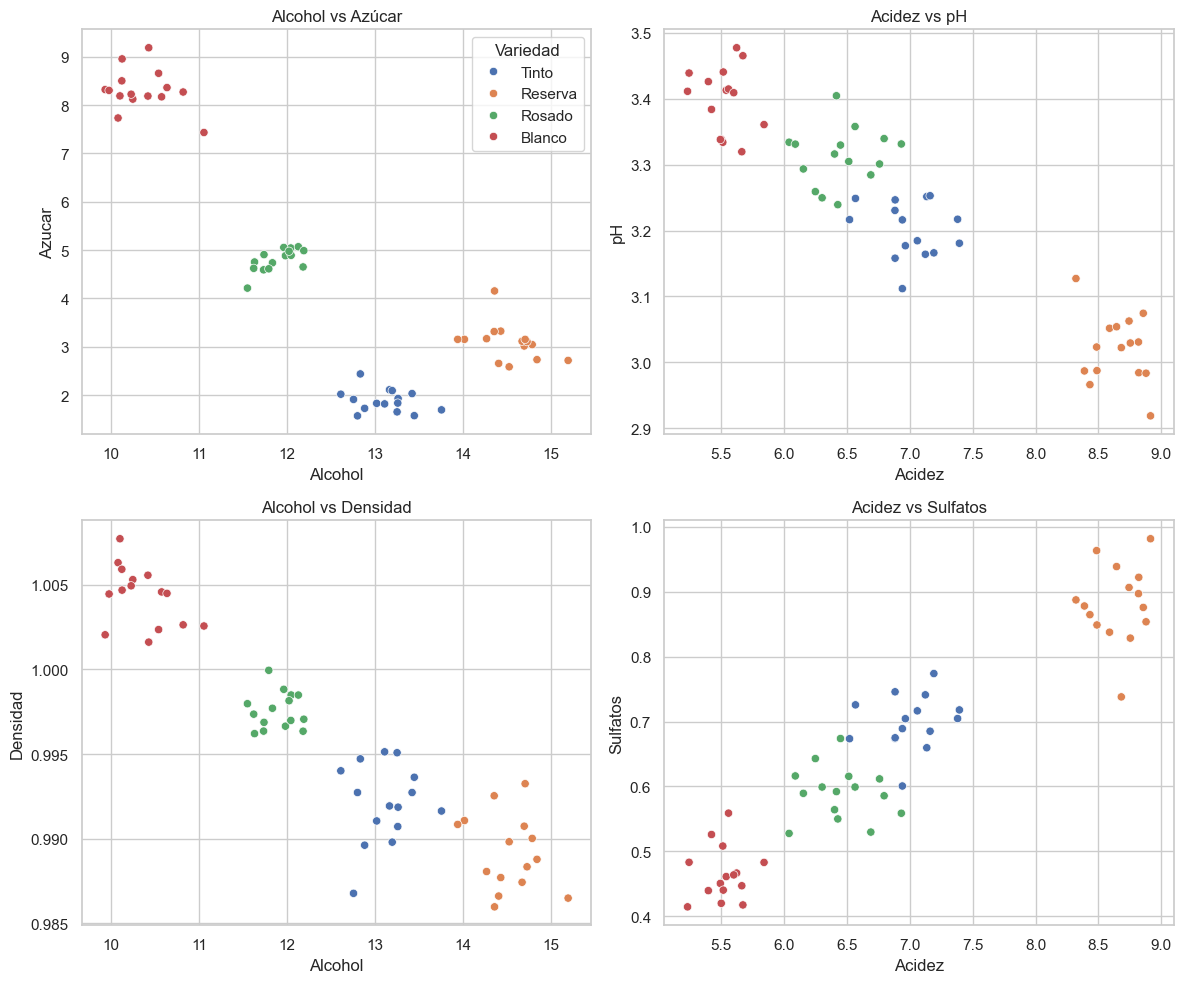

In [20]:
#Hacemos un par de gráficos para ver la relación entre algunas variables y cómo se distribuyen según la variedad de vino.
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Alcohol vs Azúcar
sns.scatterplot(
    data=vinos,
    x="Alcohol",
    y="Azucar",
    hue="Variedad",
    ax=axs[0, 0]
)
axs[0, 0].set_title("Alcohol vs Azúcar")

# Acidez vs pH
sns.scatterplot(
    data=vinos,
    x="Acidez",
    y="pH",
    hue="Variedad",
    ax=axs[0, 1]
)
axs[0, 1].set_title("Acidez vs pH")

# Alcohol vs Densidad
sns.scatterplot(
    data=vinos,
    x="Alcohol",
    y="Densidad",
    hue="Variedad",
    ax=axs[1, 0]
)
axs[1, 0].set_title("Alcohol vs Densidad")

# Acidez vs Sulfatos
sns.scatterplot(
    data=vinos,
    x="Acidez",
    y="Sulfatos",
    hue="Variedad",
    ax=axs[1, 1]
)
axs[1, 1].set_title("Acidez vs Sulfatos")

# Dejar una sola leyenda
for ax in axs.flat:
    if ax != axs[0, 0]:
        ax.get_legend().remove()

axs[0, 0].legend(title="Variedad")

plt.tight_layout()
plt.show()

Los gráficos de dispersión muestran que las distintas variedades ocupan regiones diferentes del espacio de características, algunas combinaciones de variables, como Alcohol–Azúcar o Alcohol–Densidad, permitirían distinguir mejor los grupos, mientras que otras pueden presentar un solapamiento mas notorio. En conjunto, los resultados pueden indicar que el dataset posee una estructura que podría ser identificada mediante técnicas de aprendizaje no supervisado.

---

---

## ***Procesamiento de datos***

Antes de aplicar algoritmos de aprendizaje no supervisado, es necesaria la estandarización de variables, esto debido a la diferencia de escalas entre las características. Sin escalarse previamente las variables con una magnitud mas grande podrían influir mas de lo que nos gustaría en algoritmos basados en distancias.

In [21]:
# Nos quedamos con las variables numéricas
X = vinos.drop(columns=["ID", "Variedad"])

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertimos nuevamente a DataFrame para conservar los nombres de las columnas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Acidez,Azucar,Alcohol,pH,Densidad,Sulfatos
0,0.186441,-1.102681,0.348346,-0.464618,-0.782023,0.515455
1,0.028675,-0.853308,0.229585,-0.112593,-0.177781,0.188360
2,1.649259,-0.554682,1.146726,-1.362849,-1.274451,1.494806
3,-0.127739,-0.125873,-0.590395,0.459629,0.359335,-0.297858
4,-0.333794,-1.107397,0.406006,-0.110172,-0.109172,0.090981


---

---

## ***Clustering***

### **Método del codo**

Como el dataset es "sintético" es sabido que tiene 4 variedades. Aun asi, supongamos que no lo supiéramos, en ese caso usaremos el método del codo para justificar nuestra elección.

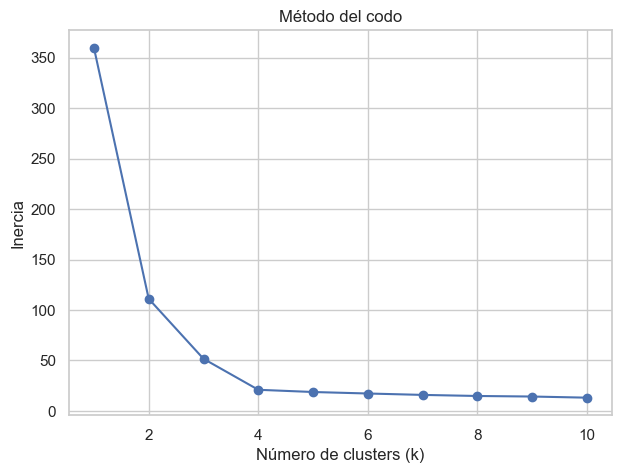

In [22]:
inercias = []
valores_k = range(1, 11)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inercias.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(valores_k, inercias, marker="o")

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")

plt.grid(True)

plt.show()

Se observa entonces que la inercia disminuye rápidamente para valores pequeños de k y a partir de aproximadamente k=4 la reducción es mucho menor. Esto nos sugiere que utilizar 4 clusters seria lo ideal para lograr una simplicidad y capacidad agradables al representar la estructura de los datos

### **Coeficiente de silueta**

Para cada punto compara que tan cerca esta su propio cluster y que tan lejos esta del cluster mas cercano y le asigna un score S tal que: $ -1 \le S \le 1$

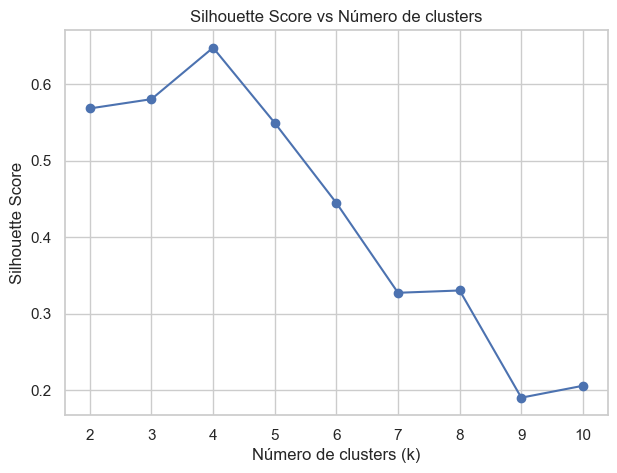

In [23]:
silhouette_scores = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7,5))

plt.plot(valores_k, silhouette_scores, marker='o')

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Número de clusters")

plt.grid(True)
plt.show()

El coeficiente de silueta alcanza su valor máximo alrededor de k=4, lo que indica una buena separación entre clusters. Este resultado es reafirma lo que con el método del codo habíamos hallado, reforzando la elección de cuatro clusters para aplicar K-Means

### **K-Means**

El método del codo mostró un cambio significativo en la pendiente de la curva al rededor de 4 sugiriendo que a partir de ese punto la reducción de la inercia resulta mas leve. Ademas, el coeficiente de la silueta alcanzo su máximo valor precisamente en $k=4$.

En conjunto ambos criterios respaldan la elección de 4 clusters para aplicar K-Means.

In [24]:
#Hacemos k-means con k=4, que es el valor que nos sugerido por los métodos del codo y del silhouette score.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

vinos["Cluster"] = clusters

#Visualizamos los primeros registros del dataset con la nueva columna de clusters asignada.
vinos.head(10)

,ID,Acidez,Azucar,Alcohol,pH,Densidad,Sulfatos,Variedad,Cluster
0,1,7.124179,1.831314,13.019488,3.164008,0.991042,0.741095,Tinto,2
1,2,6.941466,2.439695,12.833747,3.216204,0.994712,0.689016,Tinto,2
2,3,8.818309,3.168235,14.268152,3.030823,0.988050,0.897024,Reserva,0
3,4,6.760318,4.214374,11.551301,3.301050,0.997976,0.611602,Rosado,3
4,5,6.521680,1.819808,13.109669,3.216563,0.995129,0.673512,Tinto,2
5,6,6.303672,4.907105,11.739342,3.249699,0.996873,0.599049,Rosado,3
6,7,8.820618,3.017463,14.695417,2.984235,0.990732,0.922191,Reserva,0
7,8,6.402558,4.884298,11.983111,3.316208,0.996646,0.564078,Rosado,3
8,9,7.060491,2.112709,13.165306,3.184539,0.991928,0.716438,Tinto,2
9,10,6.796504,4.892190,12.047625,3.339583,0.998490,0.585567,Rosado,3


In [25]:
#Vemos la distribución de vinos por cluster para ver si los clusters obtenidos tienen una buena representación de las variedades de vino.
print("Distribución de vinos por cluster:")
print(vinos["Cluster"].value_counts())

#Hacemos una tabla cruzada para ver la distribución de variedades de vino por cluster.
pd.crosstab(vinos["Variedad"], vinos["Cluster"], margins=True, margins_name="Total")

Distribución de vinos por cluster:
Cluster
2    15
0    15
3    15
1    15
Name: count, dtype: int64


Cluster,0,1,2,3,Total
Variedad,,,,,
Blanco,0,15,0,0,15
Reserva,15,0,0,0,15
Rosado,0,0,0,15,15
Tinto,0,0,15,0,15
Total,15,15,15,15,60


Tras entrenar K-Means con k=4, se obtuvieron cuatro clusters perfectamente balanceados, cada uno con 15 observaciones. Comparar los clusters con la variable original Variedad, nos mostró una correspondencia exacta entre cada cluster y una única variedad de vino, esto nos indica que el algoritmo logró recuperar correctamente la estructura del dataset, identificando de manera precisa los cuatro grupos presentes en los datos.

## ***Resumen de Clustering***

Luego de aplicar K-Means y validar el uso de cuatro clusters mediante el método del codo y el coeficiente de silueta, resulta útil analizar visualmente la estructura encontrada. Teniendo en cuenta el resultado dado por K-Means, no se considero necesario aplicar métodos adicionales ademas de Clustering como DBSCAN o Modelo de Mezclas Gaussianas (GMM) en esta etapa, en particular: 

- DBSCAN resulta util cuando se sospecha la presencia de ruido, outliers o clusters con formas irregulares, concretamente en nuestro caso, no se observan outliers ni estructuras no convexas, ademas, K-Means ya logro separar correctamente los grupos.
- GMM es conveniente cuando es requerida una asignación probabilística de pertenencia a clusters o cuando se haya cierto solapamiento en los grupos, nuevamente, en nuestro caso, los clusters aparecen bien diferenciados por lo que no nos aporta beneficios significativos.

---

---
## ***Representacion***


### **PCA (Análisis de Componentes Principales)**

Puesto que el dataset posee 6 variables numéricas, no es posible representar directamente los datos de una forma interpretable, pues estaríamos hablando de un espacio de 6 dimensiones. Por esta razón, haremos uso de PCA con el fin de reducir la dimensionalidad a 2 componentes principales, preservando la mayor cantidad posible de variabilidad y permitiéndonos visualizar los clusters encontrados y analizar su separación en un espacio bidimensional.

In [26]:
#Aplicamos PCA para reducir la dimensionalidad a 2 componentes principales y poder visualizar los clusters obtenidos.
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#Vemos la varianza explicada por cada componente principal y vemos la varianza acumulada.
print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

print("\nVarianza acumulada:")
print(sum(pca.explained_variance_ratio_))

Varianza explicada por cada componente:
[0.89042475 0.06646187]

Varianza acumulada:
0.9568866191063354


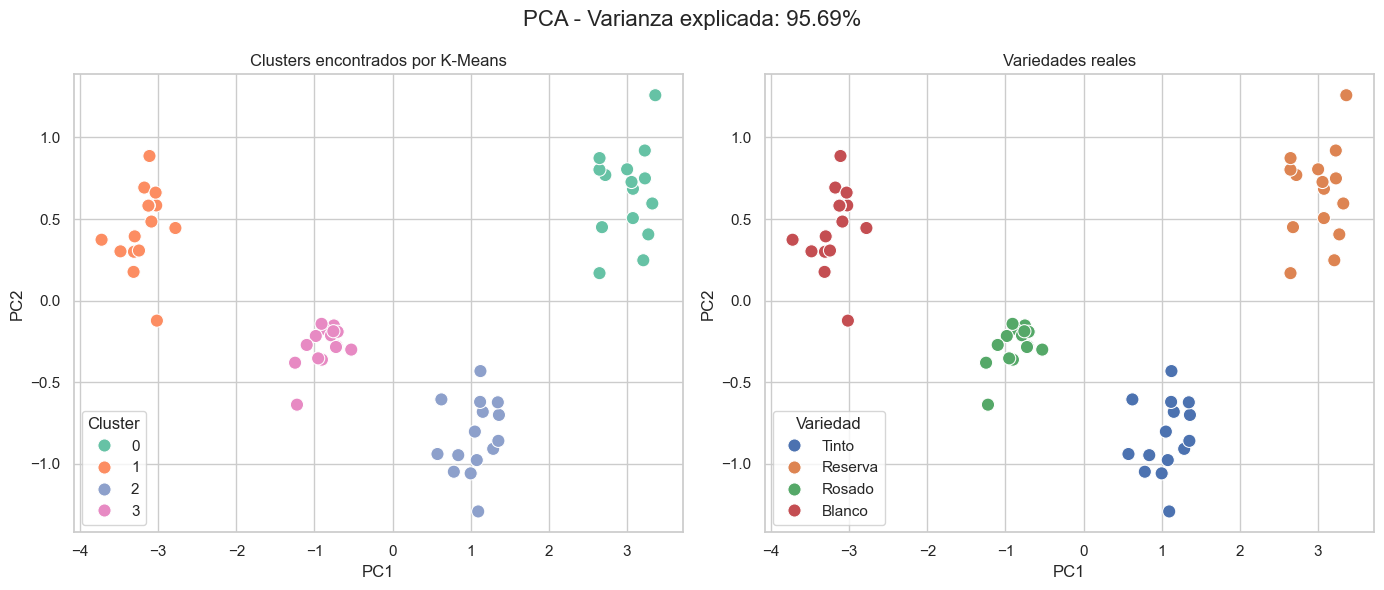

In [27]:
#Creamos un DataFrame con los resultados de PCA y los clusters asignados.
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

pca_df["Cluster"] = vinos["Cluster"].values
pca_df["Variedad"] = vinos["Variedad"].values

#Visualizamos los clusters obtenidos y las variedades reales en dos gráficos separados.
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Clusters
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=90,
    ax=axs[0]
)

axs[0].set_title("Clusters encontrados por K-Means")
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")


# Gráfico 2: Variedades reales
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Variedad",
    s=90,
    ax=axs[1]
)

axs[1].set_title("Variedades reales")
axs[1].set_xlabel("PC1")
axs[1].set_ylabel("PC2")

var_exp = sum(pca.explained_variance_ratio_) * 100
fig.suptitle(f"PCA - Varianza explicada: {var_exp:.2f}%", fontsize=16)

plt.tight_layout()
plt.show()

Tras aplicar PCA y proyectar los datos en dos componentes principales, vimos que las dos primeras componentes explican aproximadamente el 95.69% de la varianza total del dataset, esto nos dice que la estructura de los datos puede ser representada adecuadamente en un espacio bidimensional sin perder una cantidad significativa de información. La visualización muestra cuatro grupos bien diferenciados y casi nada de solapamiento entre sí, además, al comparar los clusters que obtuvimos mediante K-Means con las variedades reales de vino, se logra ver una correspondencia exacta entre ambos. Esto nos confirma que el algoritmo K-Means identifico correctamente la estructura del dataset y que la misma estructura puede visualizarse de forma clara mediante PCA.

               PC1       PC2
Acidez    0.414376  0.370217
Azucar   -0.373547  0.761745
Alcohol   0.425258 -0.009549
pH       -0.407157 -0.374309
Densidad -0.412009  0.287840
Sulfatos  0.415191  0.244198


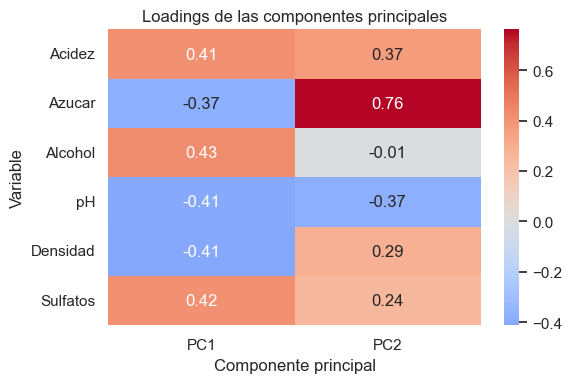

In [28]:
#Creamos un DataFrame con los loadings de las componentes principales.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print(loadings)

plt.figure(figsize=(6, 4))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Loadings de las componentes principales")
plt.xlabel("Componente principal")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

El análisis de los loadings permite interpretar el significado de las componentes principales:

- La primera componente principal (PC1) presenta contribuciones positivas importantes de las variables Acidez, Alcohol y Sulfatos, y por otro lado, contribuciones negativas de Azúcar, pH y Densidad. Esto parece indicar que PC1 separa vinos más secos, intensos y alcohólicos de vinos más dulces y densos.

- La segunda componente principal (PC2) es dominada principalmente por la variable de Azúcar, seguida por Acidez y pH. Esto nos muestra que PC2 captura principalmente diferencias asociadas al nivel de dulzura del vino.

Juntas, ambas componentes ofrecen una buena interpretación de la estructura observada en los clusters y nos permiten explicar gran parte de la variabilidad del dataset.

### **UMAP (Uniform Manifold Appoximation and Proyection)**

Si bien t-SNE es una técnica muy utilizada para visualización no lineal, decidimos utilizar UMAP debido a que preserva mejor la estructura global (y no solo la local), su mayor eficiencia y estabilidad entre ejecuciones. Esto lo convierte en una alternativa más interesante para complementar el análisis hecho con PCA.

c:\Users\mg454\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


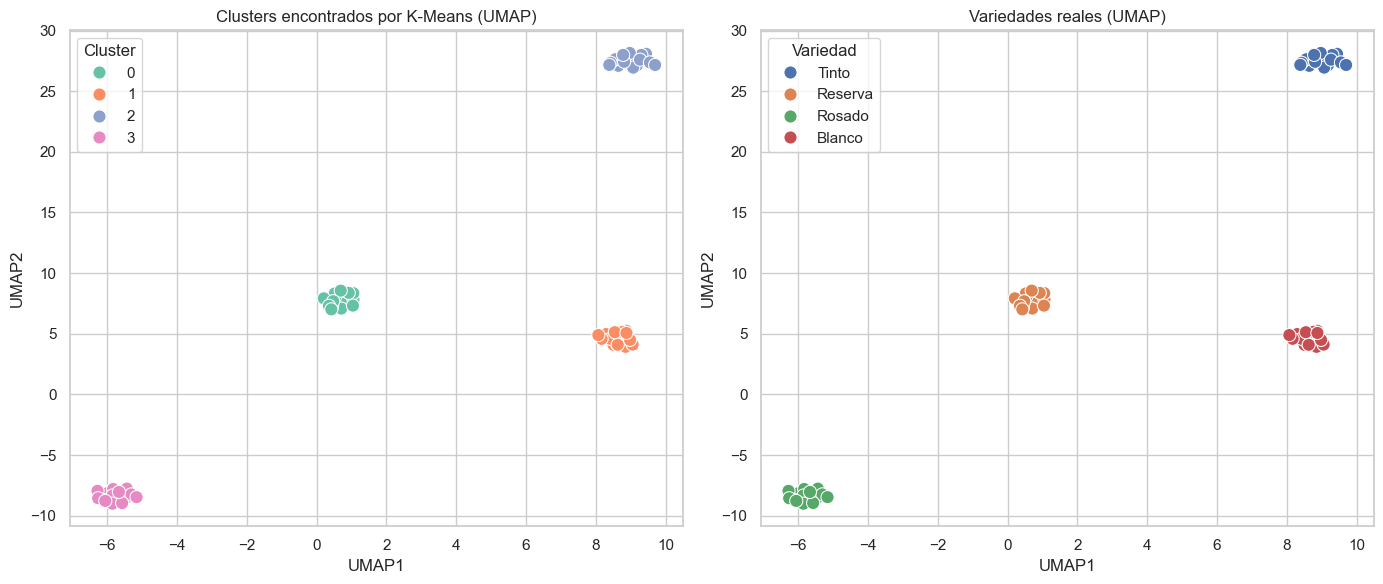

In [29]:
#Aplicamos UMAP para reducir la dimensionalidad a 2 componentes principales y poder visualizar los clusters obtenidos.
umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

#Creamos un DataFrame con los resultados de UMAP y los clusters asignados.
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

umap_df["Cluster"] = vinos["Cluster"].values
umap_df["Variedad"] = vinos["Variedad"].values

#Visualizamos los clusters obtenidos y las variedades reales en dos gráficos separados.
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Clusters encontrados
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="Set2",
    s=90,
    ax=axs[0]
)

axs[0].set_title("Clusters encontrados por K-Means (UMAP)")

# Variedades reales
sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Variedad",
    s=90,
    ax=axs[1]
)

axs[1].set_title("Variedades reales (UMAP)")

plt.tight_layout()
plt.show()

La proyección mediante UMAP nos mostró una separación muy clara entre los cuatro grupos del dataset, los clusters aparecen compactos y bien aislados entre sí, sin solapamiento, almenos visible. Al comparar la ultima visualización con la obtenida mediante PCA, se puede ver que ambas técnicas logran representar correctamente la estructura de los datos, sin embargo, UMAP produce grupos visualmente más compactos y con una separación más marcada. Esto pareciera indicar que la estructura del dataset es bastante consistente y fácilmente identificable tanto mediante técnicas lineales como no lineales de reducción de dimensionalidad.

En particular, como PCA ya explicaba el 95.69% de la varianza y permitía una separación perfecta de los grupos, podemos concluir que incluso una técnica lineal resulta suficiente para capturar la estructura de este dataset.

Otra técnica que podríamos considerar para reducción de dimensionalidad es LDA (Linear Discriminant Analysis). Sin embargo, LDA es un método supervisado, ya que requiere conocer previamente las etiquetas de clase para construir proyecciones que maximicen la separación entre grupos. En nuestro caso no se hizo el uso LDA debido a que el enfoque principal estaba mas bien centrado en técnicas no supervisadas de clustering y representación, donde las etiquetas reales (Variedad) no forman parte del entrenamiento y solo fueron empleadas posteriormente para validación e interpretación de resultados.

## ***Resumen de Representación***

Hasta ahora en el análisis se aplicaron distintas técnicas de clustering y reducción de dimensionalidad con el fin de explorar la estructura del dataset.

En primer lugar, tras estandarizar las variables, se aplicó K-Means para identificar agrupamientos naturales. Tanto el método del codo como el coeficiente de silueta indicaron que k=4 era la elección adecuada. El modelo final recuperó perfectamente los cuatro grupos que existen en el dataset y mostró una correspondencia exacta con las variedades originales de vino. Posteriormente, se aplicaron técnicas de reducción de dimensionalidad para visualizar esta estructura en un espacio bidimensional.

PCA nos permitió reducir el espacio de 6 dimensiones a 2 componentes principales, preservando aproximadamente el 96.07% de la varianza total. La proyección mostró cuatro grupos claramente diferenciados. UMAP, como técnica no lineal, generó una representación aún más compacta y visualmente separada de los clusters, confirmando la solidez de la estructura encontrada.

En conjunto, estos resultados nos indican que el dataset presenta una estructura de agrupamiento muy clara, con clusters compactos, bien separados y fácilmente identificables tanto por métodos de clustering como de representación.

---

---

## ***Densidad***

Hasta este punto, el análisis nos mostró que el dataset presenta una estructura de clustering clara y bien definida, con grupos compactos y separados entre sí, como paso complementario, resulta interesante evaluar si dentro de esta estructura existen observaciones atípicas o regiones de baja densidad que puedan considerarse anomalías. Para ello, se aplicarán distintos métodos de detección de anomalías:

- KDE (Kernel Density Estimation)
- Isolation Forest
- Local Outlier Factor (LOF)
- One-Class SVM

Debido a que estos métodos se basan en distancias, densidad o aislamiento se trabajará sobre datos previamente estandarizados.

Además, con el fin de seguir buenas prácticas, compararemos múltiples detectores para evaluar si existe consenso respecto a posibles observaciones anómalas.

### **KDE (Estimación de Densidad por Núcleo)**

KDE estima la densidad de probabilidad de los datos intuitivamente: Regiones con muchos puntos pueden indicar observaciones normales y regiones con pocos puntos observaciones potencialmente anómalas.

In [37]:
#Aplicamos KDE para estimar la densidad de los datos en el espacio reducido por PCA.
kde = KernelDensity(
    kernel='gaussian',
    bandwidth=0.5
)

kde.fit(X_pca)

#Calculamos la densidad de los datos en el espacio reducido por PCA.
log_density = kde.score_samples(X_pca)
density = np.exp(log_density)

#Creamos un DataFrame con los resultados de PCA, los clusters asignados y la densidad estimada.
pca_df["Density"] = density

print(pca_df['Density'].describe())

#Podemos ver el 10% de los datos con menor densidad para identificar posibles anomalías.
threshold = np.percentile(density, 10)

anomalies_kde = pca_df[pca_df["Density"] <= threshold]

print("\nLas posibles anomalías según KDE son:")
print(anomalies_kde)

#O cuantos son
print(f"\nCantidad de posibles anomalías según KDE: {len(anomalies_kde)}")

count    60.000000
mean      0.114985
std       0.019673
min       0.060723
25%       0.100537
50%       0.119297
75%       0.128793
max       0.142686
Name: Density, dtype: float64

Las posibles anomalías según KDE son:
         PC1       PC2  Cluster Variedad   Density
1   0.625561 -0.604610        2    Tinto  0.088400
18  3.211647  0.247598        0  Reserva  0.088963
37  3.365429  1.258439        0  Reserva  0.060723
42 -3.726333  0.373409        1   Blanco  0.081370
45  2.650640  0.168690        0  Reserva  0.069455
53 -3.017844 -0.122113        1   Blanco  0.072161

Cantidad de posibles anomalías según KDE: 6


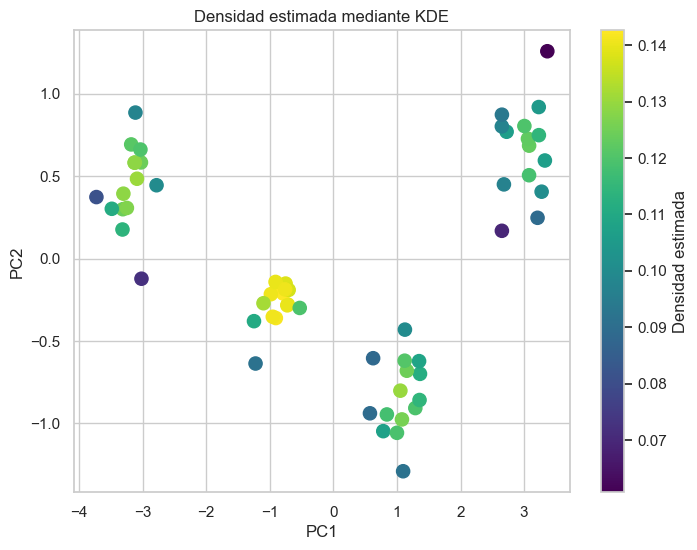

In [31]:
#Visualizamos la densidad estimada
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Density"],
    cmap="viridis",
    s=90
)

plt.colorbar(scatter, label="Densidad estimada")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Densidad estimada mediante KDE")

plt.show()

Aplicando KDE y considerando como anomalías potenciales el 10% de observaciones con menor densidad estimada, se identificaron 6 puntos candidatos. El análisis nos mostró que estas observaciones no corresponden a outliers extremos ni a puntos completamente aislados del dataset. En su lugar, se trata principalmente de observaciones ubicadas en zonas periféricas de clusters ya existentes, particularmente en las variedades Blanco, Reserva y Tinto.

Esto nos dice que el dataset no presenta anomalías severas, sino que, únicamente ciertas observaciones relativamente alejadas de los centroides de sus respectivos grupos.

### **Isolation Forest**

Luego de analizar la densidad del dataset mediante KDE, se aplica Isolation Forest como segundo método de detección de anomalías. A diferencia de KDE, que identifica anomalías a partir de regiones con baja densidad, Isolation Forest utiliza una estrategia que se basa en aislamiento. La idea central es que las observaciones anómalas suelen estar más aisladas del resto de datos, por lo que requieren menos particiones aleatorias para separarse, además, se define: contamination=0.05 este parámetro representa la proporción esperada de anomalías en el dataset.

Consideramos un valor de 5% debido a que, según el análisis previo realizado mediante clustering, PCA, UMAP y KDE, el dataset presenta una estructura muy limpia, con clusters bien definidos y sin evidencia de outliers severos. Por lo tanto, no es esperable una cantidad significativa de observaciones anómalas.

In [36]:
#Aplicamos Isolation Forest para detectar anomalías en los datos con contamination=0.05
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_labels = iso_forest.fit_predict(X_scaled)

#Guardamos resultados de Isolation Forest en el DataFrame original
vinos["Anomalia_IF"] = iso_labels

#Vemos la cantidad de posibles anomalías según Isolation Forest
print("Cantidad de posibles anomalías según Isolation Forest:", (iso_labels == -1).sum())

#Vemos cuales son las posibles anomalías según Isolation Forest
anomalies_if = vinos[vinos["Anomalia_IF"] == -1]
print("\nLas posibles anomalías según Isolation Forest son:\n")
print(anomalies_if)

Cantidad de posibles anomalías según Isolation Forest: 3

Las posibles anomalías según Isolation Forest son:

    ID    Acidez    Azucar    Alcohol        pH  Densidad  Sulfatos Variedad  \
37  38  8.914100  3.154511  13.939820  2.918743  0.990836  0.981621  Reserva   
42  43  5.674030  8.189394  10.102839  3.465357  1.007732  0.417368   Blanco   
53  54  5.234121  7.432492  11.057137  3.411373  1.002571  0.414419   Blanco   

    Cluster  Anomalia_IF  
37        0           -1  
42        1           -1  
53        1           -1  


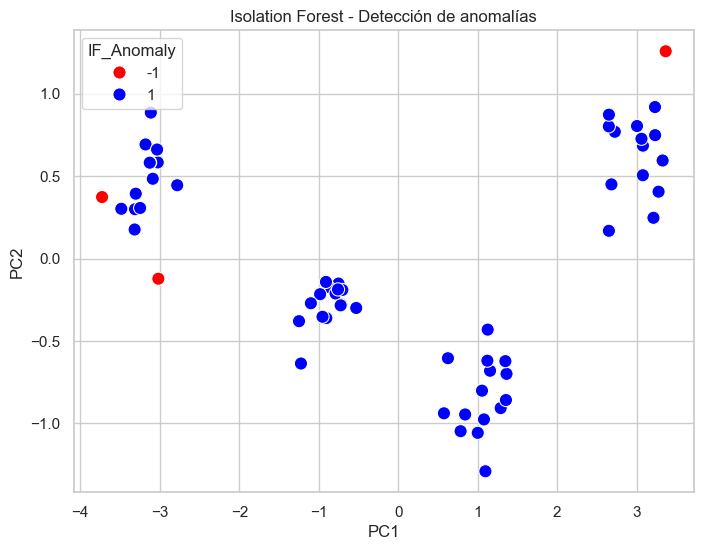

In [38]:
#Visualizamos las posibles anomalías según Isolation Forest en el espacio reducido por PCA.
pca_df["IF_Anomaly"] = iso_labels
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="IF_Anomaly",
    palette={1: "blue", -1: "red"},
    s=90
)

plt.title("Isolation Forest - Detección de anomalías")
plt.show()

Aplicamos Isolation Forest con un valor de contaminación del 5%, el modelo identificó 3 observaciones como anomalías potenciales, las mismas se ubican en regiones periféricas de los clusters que corresponden a las variedades Blanco y Reserva, coincidiendo parcialmente con las observaciones de menor densidad detectadas previamente mediante KDE. Particularmente, los puntos señalados no se corresponden a outliers extremos completamente aislados, sino a observaciones alejadas de los centroides de sus respectivos clusters, esto refuerza la conclusión de que el dataset presenta una estructura limpia y bien definida, con muy pocas observaciones potencialmente anómalas.

### **Consenso entre detectores**

Para terminar este bloque, con los puntos potencialmente anómalos hallados por ambos criterios de densidad hacemos un consenso y veremos si estos coinciden.

In [42]:
#Agregamos una columna al DataFrame original para indicar si cada observación fue marcada como anomalía por KDE o Isolation Forest.
vinos["KDE_Anomaly"] = 0
vinos.loc[anomalies_kde.index, "KDE_Anomaly"] = 1

vinos["Anomalia_IF_bin"] = (vinos["Anomalia_IF"] == -1).astype(int)

# Consenso: cuántos detectores marcaron cada observación
vinos["Anomaly_Consensus"] = vinos["KDE_Anomaly"] + vinos["Anomalia_IF_bin"]

# Ver observaciones marcadas por al menos un detector
vinos[vinos["Anomaly_Consensus"] > 0][
    ["ID", "Variedad", "KDE_Anomaly", "Anomalia_IF_bin", "Anomaly_Consensus"]
]

#Nos quedamos con las observaciones que fueron marcadas como anomalías por ambos detectores.
anomalies_consenso = vinos[vinos["Anomaly_Consensus"] == 2]

#Visualizamos
anomalies_consenso[
    ["ID", "Variedad", "KDE_Anomaly", "Anomalia_IF_bin", "Anomaly_Consensus"]
]


,ID,Variedad,KDE_Anomaly,Anomalia_IF_bin,Anomaly_Consensus
37,38,Reserva,1,1,2
42,43,Blanco,1,1,2
53,54,Blanco,1,1,2


Comparamos los resultados de KDE e Isolation Forest para analizar el consenso entre detectores, las observaciones señaladas por ambos métodos pueden considerarse candidatas más robustas a anomalía, mientras que aquellas marcadas por un solo método se interpretan como puntos periféricos o casos dudosos. En nuestro caso, lograron coincidir en que los vinos con ID's 38,43 y 54 son posibles anomalías del Dataset y, ademas, las variedades a las que pertenecen son reserva y blanco respectivamente, esto nos dice que hay pocas observaciones consistentemente atípicas, pero todas pertenecen a las variedades Blancos y Reservas, aun asi, no hay outliers severos globales, pero, sí existen algunas observaciones periféricas consistentes.

## ***Resumen de Densidad***

Como etapa final del análisis de anomalías, comparamos los resultados obtenidos por KDE e Isolation Forest para identificar observaciones detectadas por ambos métodos, el análisis de consenso mostró que únicamente 3 observaciones fueron señaladas simultáneamente por ambos detectores, correspondientes a las variedades Blanco y Reserva.

Dado que KDE e Isolation Forest utilizan criterios distintos —densidad e aislamiento, respectivamente—, estas observaciones pueden considerarse las candidatas más robustas a anomalías dentro del dataset, aun asi, incluso estas observaciones no corresponden a outliers severos completamente aislados, sino a puntos periféricos dentro de clusters ya existentes.

En conjunto, los resultados indican que el dataset presenta una estructura limpia, con clusters compactos, buena separación entre grupos y muy pocas observaciones potencialmente anómalas. Debido a esta consistencia entre ambos métodos, y teniendo en cuenta la estructura relativamente simple y bien definida del dataset, no se consideró necesario extender el análisis con detectores adicionales como Local Outlier Factor (LOF) y One-Class SVM.

En particular:

- LOF resulta útil cuando existen diferencias importantes de densidad entre clusters o anomalías locales difíciles de detectar utilizando criterios globales,en nuestro dataset, los clusters presentan densidades relativamente homogéneas y buena separación, por lo que su aporte esperado era limitado.
- One-Class SVM suele ser más utilizado en escenarios con fronteras mas complejas o no lineales entre regiones normales y anómalas, debido a que el análisis previo nos mostró una estructura clara y con muy pocas anomalías, su incorporación no aportaría información importante adicional.

Por este motivo, se consideró que KDE e Isolation Forest proporcionan evidencia suficiente para poder apreciar el comportamiento anómalo del dataset.

---

--- 

## ***Autoencoders***

Luego de analizar la representación del dataset con PCA y UMAP, nos resulta interesante incorporar un tercer enfoque de reducción de dimensionalidad basado en redes neuronales, los Autoencoders.

Hasta ahora utilizamos dos estrategias distintas de representación:
- PCA, como método lineal orientado a maximizar la varianza explicada.
- UMAP, como método no lineal orientado a mantener relaciones locales y globales entre observaciones.

Si bien ambas técnicas nos permitieron visualizar correctamente la estructura del dataset, los autoencoders introducen una perspectiva diferente, ya que aprenden de forma automática una representación comprimida de los datos a través de entrenamiento, su arquitectura se divide en dos partes principales: Encoder y decoder

En nuestro caso, el objetivo será comprimir las 6 variables originales del dataset: Acidez, Azúcar, Alcohol, pH, Densidad, Sulfatos en una representación de únicamente 2 dimensiones, de forma análoga a lo realizado con PCA y UMAP. De esta forma, nos será posible comparar tres enfoques distintos de reducción de dimensionalidad. Dado que nuestro dataset es relativamente pequeño, limpio y presenta una estructura de clustering bien definida, utilizaremos una arquitectura simple de autoencoder, suficiente para capturar la estructura principal de los datos sin introducir complejidad innecesaria.

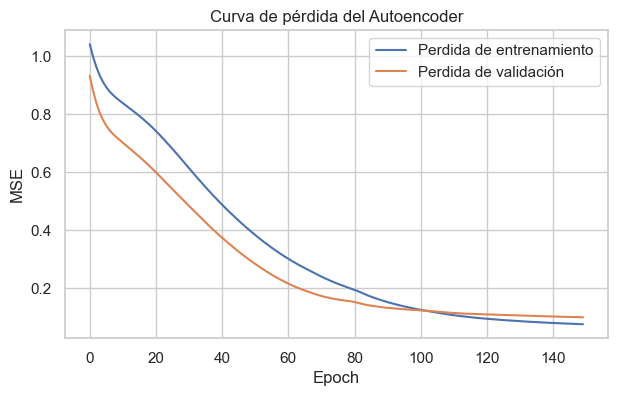

In [49]:
#Construimos nuestro autoencoder para detectar anomalías
input_dim = X_scaled.shape[1]
encoding_dim = 2

#Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(4, activation='relu')(input_layer)
latent = Dense(encoding_dim, activation='linear')(encoded)

#Decoder
decoded = Dense(4, activation='relu')(latent)
output_layer = Dense(input_dim, activation='linear')(decoded)

#Construimos el modelo completo
autoencoder = Model(inputs=input_layer, outputs=output_layer)

#Modelo encoder por separado
encoder = Model(inputs=input_layer, outputs=latent)

#Compilamos el autoencoder
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

#Entrenamos el autoencoder, usamos pocas épocas pues el dataset es pequeño y queremos evitar overfitting.
history = autoencoder.fit(
    X_scaled,
    X_scaled,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

#Graficamos la curva de perdida
plt.figure(figsize=(7,4))

plt.plot(history.history['loss'], label='Perdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Perdida de validación')

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Curva de pérdida del Autoencoder")
plt.legend()

plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


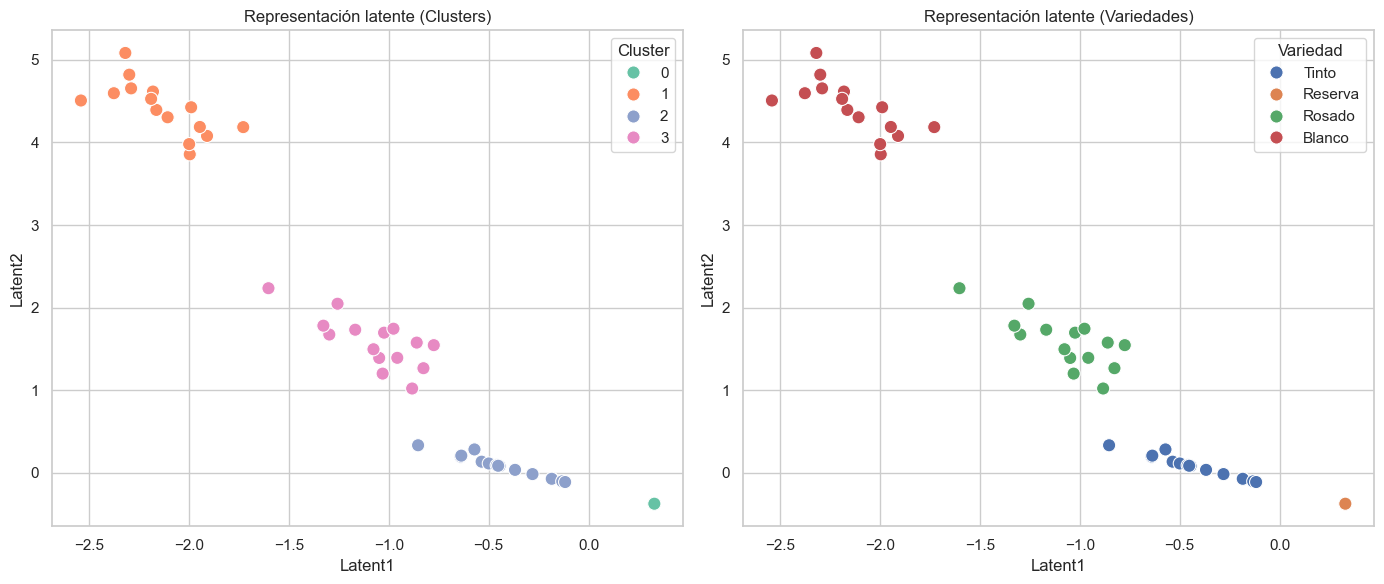

In [50]:
#Obtenemos la representación latente utilizando el encoder del autoencoder
latent_space = encoder.predict(X_scaled)

#Creamos un DataFrame con la representación latente y los clusters asignados.
latent_df = pd.DataFrame(latent_space, columns=["Latent1", "Latent2"])

latent_df["Cluster"] = vinos["Cluster"].values
latent_df["Variedad"] = vinos["Variedad"].values

#Visualizamos la representación latente obtenida por el autoencoder y los clusters asignados.
fig, axs = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    data=latent_df,
    x="Latent1",
    y="Latent2",
    hue="Cluster",
    palette="Set2",
    s=90,
    ax=axs[0]
)

axs[0].set_title("Representación latente (Clusters)")

sns.scatterplot(
    data=latent_df,
    x="Latent1",
    y="Latent2",
    hue="Variedad",
    s=90,
    ax=axs[1]
)

axs[1].set_title("Representación latente (Variedades)")

plt.tight_layout()
plt.show()

El autoencoder nos mostró una convergencia estable durante el entrenamiento, con una reducción sostenida tanto de la pérdida de entrenamiento como de validación, la similitud entre ambas curvas nos dice que el modelo logró aprender una representación comprimida efectiva sin alguna evidencia significativa de sobreajuste.

La representación latente de 2 dimensiones que obtuvimos por medio de el Encoder mostró una separación clara entre las distintas variedades de vino, preservando adecuadamente la estructura de clustering que observamos previamente con K-Means.

Comparando estos resultados con PCA y UMAP, se puede ver que el autoencoder también logró representar correctamente la estructura del dataset, manteniendo clusters compactos y bien diferenciados, esto nos indica que una arquitectura neuronal simple resulta suficiente para capturar las relaciones principales entre las variables del dataset.

---

---

# ***Conclusiones***

A lo largo de este trabajo construimos y analizamos un dataset sintético de vinos compuesto por 60 observaciones, 6 variables numéricas y 4 variedades distintas. Nuestro objetivo principal fue estudiar la estructura de los datos mediante técnicas de clustering, reducción de dimensionalidad, detección de anomalías y representación aprendida.

En primera instancia, se realizó una exploración descriptiva del dataset y un preprocesamiento que se basó en estandarización de variables, paso importante al momento de garantizar un correcto funcionamiento de los métodos posteriores basados en distancias, densidad y optimización.

En la etapa de clustering, se aplicó K-Means, utilizando el método del codo y el coeficiente de silueta para seleccionar el número adecuado de clusters. Ambos criterios indicaron de manera consistente que k=4 era la elección óptima. El modelo logró recuperar perfectamente la estructura original del dataset, generando asi, una correspondencia exacta entre los clusters obtenidos y las variedades reales de vino.

Posteriormente, aplicamos técnicas de reducción de dimensionalidad con la finalidad de visualizar la estructura de los datos en espacios bidimensionales. PCA nos permitió reducir el espacio de 6 variables a 2 componentes principales, preservando en el proceso, aproximadamente el 96% de la varianza total, y la proyección mostró una separación clara entre las cuatro variedades. UMAP, por su parte como técnica no lineal, generó una representación todavía más compacta y visualmente separada, confirmándonos la solidez de la estructura observada. En conjunto, ambas técnicas mostraron que el dataset presenta clusters compactos, bien definidos y fácilmente separables.

En la etapa de análisis de densidad y detección de anomalías, utilizamos KDE e Isolation Forest para estudiar la presencia de observaciones atípicas. KDE identificó regiones de alta densidad en los centros de los clusters y detectó algunas observaciones periféricas de mas baja densidad. Isolation Forest detectó un número reducido de anomalías potenciales, consistente con la estructura limpia del dataset. Luego, el análisis de consenso entre ambos métodos mostró que únicamente 3 observaciones fueron detectadas simultáneamente como anomalías, aun asi, estas no corresponden a outliers severos, sino a observaciones periféricas dentro de clusters existentes. Con esto sobre la mesa, pudimos concluir que el dataset presenta una estructura limpia y con muy pocas anomalías relevantes, cosa que resultaba esperable dados los resultados anteriores.

Finalmente, utilizamos un Autoencoder como enfoque de reducción de dimensionalidad basado en redes neuronales. El modelo mostró una convergencia estable durante el entrenamiento, sin alguna evidencia significativa de sobreajuste. La representación latente de 2 dimensiones, posteriormente, logró preservar correctamente la estructura de clustering, separando de manera clara las distintas variedades de vino.

Esto ultimo nos permitió comparar exitosamente tres enfoques distintos de representación:

- PCA → reducción lineal
- UMAP → reducción no lineal basada en vecinos
- Autoencoder → reducción no lineal aprendida mediante redes neuronales

A modo de conclusión general, los resultados obtenidos muestran que el dataset posee una estructura bastante consistente, con grupos bien definidos, buena separación entre clases y escasas anomalías. Todas las técnicas aplicadas —desde clustering clásico hasta métodos avanzados de representación— coincidieron en describir una estructura clara y estable.

Este trabajo nos permitió, no solo aplicar múltiples herramientas de aprendizaje no supervisado, sino también jugar un poco con ellas y, a su vez comparar sus fortalezas, limitaciones y contextos de uso.